##  Sentiment Analysis

FinBERT is applied to the validated sustainability-report corpus to estimate the tone of corporate disclosures.

The analysis uses minimally cleaned text because transformer-based sentiment classification depends on sentence structure, negation and contextual meaning. The LDA-specific tokens are therefore not used.

Sentiment outputs will subsequently be aggregated to company level and compared with thematic disclosure patterns and LSEG ESG performance.

## 6.1 Import Libraries and Define Paths

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np


PROJECT_DIR = Path(
    r"C:\Users\techi\Desktop\Greenwashing_Disssertation"
)

LDA_INPUT_PATH = (
    PROJECT_DIR
    / "Data"
    / "LDA_Outputs"
    / "Chunks_with_Full_LDA_Distributions.csv"
)

SENTIMENT_OUTPUT_DIR = (
    PROJECT_DIR
    / "Data"
    / "Sentiment_Outputs"
)

SENTIMENT_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("Python executable:", sys.executable)
print("Input file exists:", LDA_INPUT_PATH.exists())
print("Sentiment output folder:", SENTIMENT_OUTPUT_DIR)

Python executable: C:\Users\techi\.conda\envs\notebook-env\python.exe
Input file exists: True
Sentiment output folder: C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Sentiment_Outputs


## 6.2 Load the Chunk-Level Dataset

The sentiment notebook begins from the validated chunk-level output produced during topic modelling. This avoids repeating PDF extraction, cleaning and segmentation.

In [2]:
sentiment_df = pd.read_csv(
    LDA_INPUT_PATH
)

print("Dataset shape:", sentiment_df.shape)
print("Companies represented:", sentiment_df["Company_ID"].nunique())

sentiment_df.head()

Dataset shape: (2895, 28)
Companies represented: 25


,Company_ID,Chunk_ID,Chunk_Number,Word_Count,Text,LDA_Tokens,LDA_Token_Count,LDA_Bigram_Tokens,LDA_Bigram_Token_Count,LDA_Final_Tokens,...,Topic_5_Probability,Topic_6_Probability,Topic_7_Probability,Topic_8_Probability,Topic_9_Probability,Topic_10_Probability,Topic_11_Probability,Topic_12_Probability,Topic_13_Probability,Topic_14_Probability
0,C01,C01_CH0001,1,296,30 Vodafone Group Plc Annual Report 2025 Gover...,"['vodafone', 'governance', 'purpose', 'sustain...",153,"['vodafone_governance', 'purpose', 'sustainabi...",130,"['vodafone_governance', 'purpose', 'sustainabi...",...,0.000187,0.369228,0.324658,0.000520,0.039989,0.118814,0.000546,0.000321,0.142552,0.000417
1,C01,C01_CH0002,2,298,Empowering customers We strive to provide rele...,"['empower', 'customer', 'strive', 'provide', '...",149,"['empower', 'customer', 'strive', 'provide', '...",132,"['empower', 'customer', 'strive', 'provide', '...",...,0.000187,0.297552,0.170212,0.000520,0.089795,0.000474,0.086684,0.000321,0.000646,0.000417
2,C01,C01_CH0003,3,300,Vodafone Group Plc Annual Report 2025 31 Gover...,"['vodafone', 'governance', 'esg', 'governance'...",159,"['vodafone_governance', 'esg', 'governance_str...",149,"['vodafone_governance', 'esg', 'governance_str...",...,0.000171,0.022628,0.000770,0.638425,0.000556,0.000434,0.000499,0.035706,0.000592,0.000381
3,C01,C01_CH0004,4,290,"In FY26, we aim to increase the frequency of j...","['aim', 'increase', 'frequency', 'joint', 'mee...",160,"['aim', 'increase', 'frequency', 'joint', 'mee...",140,"['aim', 'increase', 'frequency', 'joint', 'mee...",...,0.000179,0.285471,0.116498,0.288535,0.000581,0.000453,0.015532,0.000307,0.175405,0.000398
4,C01,C01_CH0005,5,266,32 Vodafone Group Plc Annual Report 2025 Gover...,"['vodafone', 'governance', 'esg', 'disclosure'...",186,"['vodafone_governance', 'esg', 'disclosure', '...",153,"['vodafone_governance', 'esg', 'disclosure', '...",...,0.000175,0.135020,0.152567,0.170591,0.030367,0.012137,0.148631,0.000300,0.000605,0.052038


## 6.3 Validate Required Columns

Only the original chunk text and identifying variables are required for sentiment analysis.

In [3]:
required_columns = {
    "Company_ID",
    "Chunk_ID",
    "Chunk_Number",
    "Word_Count",
    "Text"
}

missing_columns = (
    required_columns
    - set(sentiment_df.columns)
)

assert not missing_columns, (
    f"Required columns are missing: {missing_columns}"
)

assert sentiment_df["Text"].notna().all(), (
    "Some chunks contain missing text."
)

assert sentiment_df["Chunk_ID"].is_unique, (
    "Chunk identifiers are not unique."
)

print("Dataset validation successful.")
print("Chunks available:", len(sentiment_df))
print("Companies represented:", sentiment_df["Company_ID"].nunique())

Dataset validation successful.
Chunks available: 2895
Companies represented: 25


## 6.4 FinBERT Environment Setup

FinBERT requires PyTorch and the Hugging Face Transformers library. The dependencies are checked before installation to avoid unnecessary changes to the environment.

In [5]:
%pip install torch transformers

   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
    --------------------------------------- 2.1/122.1 MB 11.2 MB/s eta 0:00:11
   - -------------------------------------- 4.7/122.1 MB 12.2 MB/s eta 0:00:10
   -- ------------------------------------- 7.3/122.1 MB 12.1 MB/s eta 0:00:10
   --- ------------------------------------ 9.7/122.1 MB 12.1 MB/s eta 0:00:10
   ---- ----------------------------------- 12.3/122.1 MB 12.1 MB/s eta 0:00:10
   ---- ----------------------------------- 14.7/122.1 MB 12.0 MB/s eta 0:00:09
   ----- ---------------------------------- 17.0/122.1 MB 11.9 MB/s eta 0:00:09
   ------ --------------------------------- 19.7/122.1 MB 11.9 MB/s eta 0:00:09
   ------- -------------------------------- 22.0/122.1 MB 11.9 MB/s eta 0:00:09
   -------- ------------------------------- 24.6/122.1 MB 11.9 MB/s eta 0:00:09
   -------- ------------------------------- 27.0/122.1 MB 11.9 MB/s eta 0:00:08
   --------- ------------------------------ 29.6/122.

In [6]:
# Check whether the required packages are installed

import importlib.util

required_packages = {
    "torch": importlib.util.find_spec("torch"),
    "transformers": importlib.util.find_spec("transformers")
}

for package, package_spec in required_packages.items():
    status = "Installed" if package_spec is not None else "Not installed"
    print(f"{package}: {status}")

torch: Installed
transformers: Installed


In [7]:
import torch
import transformers

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

C:\Users\techi\.conda\envs\notebook-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.13.0+cpu
Transformers version: 5.14.1
CUDA available: False


## 6.5 Load the FinBERT Model

The ProsusAI FinBERT model is loaded using the Hugging Face tokenizer and sequence-classification model.

The model produces positive, negative and neutral sentiment probabilities. CPU processing is used because CUDA acceleration is unavailable.

In [8]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

FINBERT_MODEL_NAME = "ProsusAI/finbert"

finbert_tokenizer = AutoTokenizer.from_pretrained(
    FINBERT_MODEL_NAME
)

finbert_model = AutoModelForSequenceClassification.from_pretrained(
    FINBERT_MODEL_NAME
)

finbert_model.eval()

print("FinBERT model loaded successfully.")
print("Label mapping:", finbert_model.config.id2label)

C:\Users\techi\.conda\envs\notebook-env\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\techi\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7251.90it/s]

FinBERT model loaded successfully.
Label mapping: {0: 'positive', 1: 'negative', 2: 'neutral'}


## 6.7 Sample-Based FinBERT Validation

Before full-corpus inference, FinBERT is tested on a small sample of sustainability-report chunks.

This confirms that the tokenizer, model and sentiment-label mapping operate correctly before computationally intensive processing is applied to the complete corpus.

In [9]:
import torch
import torch.nn.functional as F

sample_texts = sentiment_df["Text"].head(5).tolist()

encoded_sample = finbert_tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=512,
    return_tensors="pt"
)

with torch.no_grad():
    sample_outputs = finbert_model(**encoded_sample)

sample_probabilities = F.softmax(
    sample_outputs.logits,
    dim=1
)

sample_results = []

for text, probabilities in zip(
    sample_texts,
    sample_probabilities
):
    probabilities = probabilities.cpu().numpy()

    positive_score = float(probabilities[0])
    negative_score = float(probabilities[1])
    neutral_score = float(probabilities[2])

    dominant_index = int(probabilities.argmax())
    sentiment_label = finbert_model.config.id2label[
        dominant_index
    ]

    sample_results.append({
        "Text_Preview": text[:150],
        "Positive_Probability": positive_score,
        "Negative_Probability": negative_score,
        "Neutral_Probability": neutral_score,
        "Sentiment_Label": sentiment_label
    })

sample_results_df = pd.DataFrame(sample_results)

sample_results_df

,Text_Preview,Positive_Probability,Negative_Probability,Neutral_Probability,Sentiment_Label
0,30 Vodafone Group Plc Annual Report 2025 Gover...,0.353195,0.010730,0.636075,neutral
1,Empowering customers We strive to provide rele...,0.079904,0.014354,0.905741,neutral
2,Vodafone Group Plc Annual Report 2025 31 Gover...,0.035824,0.015645,0.948531,neutral
3,"In FY26, we aim to increase the frequency of j...",0.137105,0.011061,0.851835,neutral
4,32 Vodafone Group Plc Annual Report 2025 Gover...,0.029460,0.030061,0.940478,neutral


In [10]:
# validate the probability totals 

sample_results_df["Probability_Total"] = (
    sample_results_df[
        [
            "Positive_Probability",
            "Negative_Probability",
            "Neutral_Probability"
        ]
    ].sum(axis=1)
)

print(
    sample_results_df[
        [
            "Sentiment_Label",
            "Probability_Total"
        ]
    ]
)

  Sentiment_Label  Probability_Total
0         neutral                1.0
1         neutral                1.0
2         neutral                1.0
3         neutral                1.0
4         neutral                1.0


## 6.8 Inspect Sample Sentiment Probabilities

The sample praedictions are reviewed to confirm the strength of the neutral classifications.

In [11]:
sample_results_df[
    [
        "Text_Preview",
        "Positive_Probability",
        "Negative_Probability",
        "Neutral_Probability",
        "Sentiment_Label"
    ]
]

,Text_Preview,Positive_Probability,Negative_Probability,Neutral_Probability,Sentiment_Label
0,30 Vodafone Group Plc Annual Report 2025 Gover...,0.353195,0.010730,0.636075,neutral
1,Empowering customers We strive to provide rele...,0.079904,0.014354,0.905741,neutral
2,Vodafone Group Plc Annual Report 2025 31 Gover...,0.035824,0.015645,0.948531,neutral
3,"In FY26, we aim to increase the frequency of j...",0.137105,0.011061,0.851835,neutral
4,32 Vodafone Group Plc Annual Report 2025 Gover...,0.029460,0.030061,0.940478,neutral


## 6.9 Validate FinBERT Input Lengths

FinBERT accepts a maximum of 512 tokens. Token lengths are therefore measured before full-corpus inference to determine whether any chunks require further segmentation.

In [12]:
# Calculate FinBERT token length for every chunk

sentiment_df["FinBERT_Token_Count"] = sentiment_df["Text"].apply(
    lambda text: len(
        finbert_tokenizer.encode(
            text,
            add_special_tokens=True,
            truncation=False
        )
    )
)

print("FINBERT TOKEN-LENGTH SUMMARY")
print("-" * 50)

print(
    "Mean tokens:",
    round(sentiment_df["FinBERT_Token_Count"].mean(), 1)
)

print(
    "Median tokens:",
    round(sentiment_df["FinBERT_Token_Count"].median(), 1)
)

print(
    "Maximum tokens:",
    sentiment_df["FinBERT_Token_Count"].max()
)

print(
    "Chunks exceeding 512 tokens:",
    (sentiment_df["FinBERT_Token_Count"] > 512).sum()
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (708 > 512). Running this sequence through the model will result in indexing errors


FINBERT TOKEN-LENGTH SUMMARY
--------------------------------------------------
Mean tokens: 358.9
Median tokens: 359.0
Maximum tokens: 854
Chunks exceeding 512 tokens: 58


## 6.10 Construct FinBERT-Compatible Text Segments

FinBERT accepts a maximum sequence length of 512 tokens, including special tokens. Chunks exceeding this limit are therefore divided into smaller sentence-aware segments.

Each segment retains its original company and chunk identifiers so that sentiment probabilities can later be recombined at chunk and company levels.

In [13]:
import re


MAX_FINBERT_TOKENS = 510
# Leaves space for the model's special tokens


def split_text_for_finbert(
    text,
    tokenizer,
    max_tokens=MAX_FINBERT_TOKENS
):
    """
    Divide text into sentence-aware FinBERT segments.

    Sentences are retained intact whenever possible.
    A sentence exceeding the maximum length is split by token IDs.
    """

    # Basic sentence-boundary detection
    sentences = re.split(
        r"(?<=[.!?])\s+",
        str(text).strip()
    )

    segments = []
    current_sentences = []
    current_token_count = 0

    for sentence in sentences:

        sentence = sentence.strip()

        if not sentence:
            continue

        sentence_token_ids = tokenizer.encode(
            sentence,
            add_special_tokens=False
        )

        sentence_token_count = len(
            sentence_token_ids
        )

        # Handle an unusually long sentence-like unit
        if sentence_token_count > max_tokens:

            # Save the existing segment first
            if current_sentences:
                segments.append(
                    " ".join(current_sentences)
                )

                current_sentences = []
                current_token_count = 0

            # Hard-split only the oversized sentence
            for start in range(
                0,
                sentence_token_count,
                max_tokens
            ):
                token_slice = sentence_token_ids[
                    start:start + max_tokens
                ]

                segment_text = tokenizer.decode(
                    token_slice,
                    skip_special_tokens=True,
                    clean_up_tokenization_spaces=True
                )

                if segment_text.strip():
                    segments.append(
                        segment_text.strip()
                    )

            continue

        # Save the current segment if the sentence would exceed the limit
        if (
            current_sentences
            and
            current_token_count + sentence_token_count
            > max_tokens
        ):
            segments.append(
                " ".join(current_sentences)
            )

            current_sentences = []
            current_token_count = 0

        current_sentences.append(sentence)
        current_token_count += sentence_token_count

    # Save the final segment
    if current_sentences:
        segments.append(
            " ".join(current_sentences)
        )

    return segments

## 6.11 Expand the Corpus into FinBERT Units

Each original chunk is converted into one or more FinBERT-compatible units. The relationship between every segment and its original chunk is preserved.

In [14]:
finbert_segment_records = []


for row in sentiment_df.itertuples(index=False):

    segments = split_text_for_finbert(
        text=row.Text,
        tokenizer=finbert_tokenizer,
        max_tokens=MAX_FINBERT_TOKENS
    )

    total_segments = len(segments)

    for segment_number, segment_text in enumerate(
        segments,
        start=1
    ):

        segment_token_count = len(
            finbert_tokenizer.encode(
                segment_text,
                add_special_tokens=True,
                truncation=False
            )
        )

        finbert_segment_records.append({
            "Company_ID": row.Company_ID,
            "Chunk_ID": row.Chunk_ID,
            "Chunk_Number": row.Chunk_Number,
            "Segment_ID":
                f"{row.Chunk_ID}_S{segment_number:02d}",
            "Segment_Number": segment_number,
            "Segments_in_Chunk": total_segments,
            "Segment_Token_Count": segment_token_count,
            "Text": segment_text
        })


finbert_segments_df = pd.DataFrame(
    finbert_segment_records
)

print(
    "Original chunks:",
    len(sentiment_df)
)

print(
    "FinBERT segments:",
    len(finbert_segments_df)
)

print(
    "Chunks requiring multiple segments:",
    finbert_segments_df.loc[
        finbert_segments_df["Segments_in_Chunk"] > 1,
        "Chunk_ID"
    ].nunique()
)

print(
    "Maximum segment token count:",
    finbert_segments_df[
        "Segment_Token_Count"
    ].max()
)

Original chunks: 2895
FinBERT segments: 2966
Chunks requiring multiple segments: 58
Maximum segment token count: 512


## 6.12 Validate FinBERT Segmentation

Every original chunk must appear in the segmented corpus, and no segment may exceed the 512-token model limit.

In [15]:
assert (
    finbert_segments_df["Chunk_ID"].nunique()
    == sentiment_df["Chunk_ID"].nunique()
), "Some original chunks are missing from the segmented corpus."


assert (
    finbert_segments_df["Segment_Token_Count"].max()
    <= 512
), "At least one FinBERT segment exceeds 512 tokens."


assert (
    finbert_segments_df["Text"]
    .notna()
    .all()
), "At least one segment contains missing text."


assert (
    finbert_segments_df["Segment_ID"]
    .is_unique
), "Segment identifiers are not unique."


print("FinBERT segmentation validated successfully.")

FinBERT segmentation validated successfully.


## 6.13 Run FinBERT Sentiment Inference

FinBERT is applied to all validated text segments in small batches suitable for CPU processing. Positive, negative and neutral probabilities are retained for each segment.

In [17]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


BATCH_SIZE = 8

segment_texts = finbert_segments_df["Text"].tolist()

sentiment_results = []


for batch_start in tqdm(
    range(0, len(segment_texts), BATCH_SIZE),
    desc="Running FinBERT"
):

    batch_texts = segment_texts[
        batch_start:batch_start + BATCH_SIZE
    ]

    encoded_batch = finbert_tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    with torch.no_grad():
        batch_outputs = finbert_model(
            **encoded_batch
        )

    batch_probabilities = torch.softmax(
        batch_outputs.logits,
        dim=1
    ).cpu().numpy()

    for probabilities in batch_probabilities:

        positive_probability = float(
            probabilities[0]
        )

        negative_probability = float(
            probabilities[1]
        )

        neutral_probability = float(
            probabilities[2]
        )

        dominant_index = int(
            probabilities.argmax()
        )

        sentiment_label = (
            finbert_model
            .config
            .id2label[dominant_index]
        )

        sentiment_results.append({
            "Positive_Probability":
                positive_probability,

            "Negative_Probability":
                negative_probability,

            "Neutral_Probability":
                neutral_probability,

            "Sentiment_Label":
                sentiment_label
        })


sentiment_results_df = pd.DataFrame(
    sentiment_results
)

print(
    "Segments processed:",
    len(sentiment_results_df)
)

sentiment_results_df.head()

Running FinBERT: 100%|██████████| 371/371 [1:31:22<00:00, 14.78s/it]


Segments processed: 2966


,Positive_Probability,Negative_Probability,Neutral_Probability,Sentiment_Label
0,0.353195,0.010730,0.636075,neutral
1,0.079904,0.014354,0.905741,neutral
2,0.035824,0.015645,0.948531,neutral
3,0.137105,0.011061,0.851835,neutral
4,0.029460,0.030061,0.940478,neutral


## 6.14 Validate and Attach Segment-Level Sentiment

The number of sentiment predictions must match the number of FinBERT segments, and each probability distribution must sum to approximately one.

In [18]:
assert (
    len(sentiment_results_df)
    == len(finbert_segments_df)
), "Sentiment results do not match the number of FinBERT segments."


segment_probability_totals = (
    sentiment_results_df[
        [
            "Positive_Probability",
            "Negative_Probability",
            "Neutral_Probability"
        ]
    ].sum(axis=1)
)


assert np.allclose(
    segment_probability_totals,
    1.0,
    atol=1e-5
), "Some FinBERT probabilities do not sum to 1."


finbert_segments_df = pd.concat(
    [
        finbert_segments_df.reset_index(
            drop=True
        ),
        sentiment_results_df.reset_index(
            drop=True
        )
    ],
    axis=1
)


print(
    "Segment-level sentiment validated successfully."
)

print(
    finbert_segments_df[
        "Sentiment_Label"
    ].value_counts()
)

Segment-level sentiment validated successfully.
Sentiment_Label
neutral     2233
positive     659
negative      74
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Validated FinBERT sentiment counts

sentiment_plot_df = pd.DataFrame({
    "Sentiment": [
        "Neutral",
        "Positive",
        "Negative"
    ],
    "Count": [
        2233,
        659,
        74
    ]
})

# Convert counts to percentages

sentiment_plot_df["Percentage"] = (
    sentiment_plot_df["Count"]
    / sentiment_plot_df["Count"].sum()
    * 100
)

display(sentiment_plot_df)

,Sentiment,Count,Percentage
0,Neutral,2233,75.286581
1,Positive,659,22.218476
2,Negative,74,2.494943


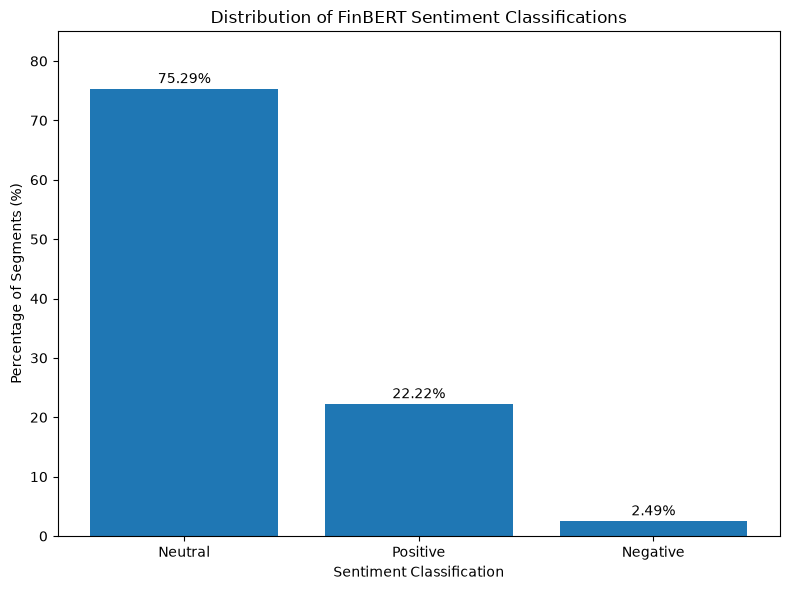

Figure saved to:
C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Final_Datasets\FinBERT_Sentiment_Distribution.png


In [15]:
from pathlib import Path
import matplotlib.pyplot as plt

# Define output folder directly
figure_output_dir = Path(
    r"C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Final_Datasets"
)

# Create folder if necessary
figure_output_dir.mkdir(parents=True, exist_ok=True)

figure_path = (
    figure_output_dir
    / "FinBERT_Sentiment_Distribution.png"
)

# Recreate figure for saving
plt.figure(figsize=(8, 6))

bars = plt.bar(
    sentiment_plot_df["Sentiment"],
    sentiment_plot_df["Percentage"]
)

plt.xlabel("Sentiment Classification")
plt.ylabel("Percentage of Segments (%)")
plt.title("Distribution of FinBERT Sentiment Classifications")
plt.ylim(0, 85)

for bar, value in zip(
    bars,
    sentiment_plot_df["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

## 6.15 Create a FinBERT Sentiment Score

A continuous sentiment score is calculated as positive probability minus negative probability. Scores range approximately from -1 to +1.

In [19]:
finbert_segments_df["FinBERT_Sentiment_Score"] = (
    finbert_segments_df[
        "Positive_Probability"
    ]
    -
    finbert_segments_df[
        "Negative_Probability"
    ]
)


print(
    finbert_segments_df[
        "FinBERT_Sentiment_Score"
    ].describe()
)

count    2966.000000
mean        0.209853
std         0.315174
min        -0.957437
25%         0.012336
50%         0.110550
75%         0.416869
max         0.941504
Name: FinBERT_Sentiment_Score, dtype: float64


## 6.16 Aggregate Segment Sentiment to Original Chunks

A small number of chunks were divided into multiple FinBERT segments.

To maintain consistency with the original analytical unit used throughout the dissertation, the segment-level predictions are aggregated back to the original chunk level by averaging the sentiment probabilities.

In [20]:
# Average sentiment probabilities for each original chunk

chunk_sentiment = (
    finbert_segments_df
    .groupby(
        [
            "Company_ID",
            "Chunk_ID",
            "Chunk_Number"
        ],
        as_index=False
    )
    .agg(
        Positive_Probability=(
            "Positive_Probability",
            "mean"
        ),
        Negative_Probability=(
            "Negative_Probability",
            "mean"
        ),
        Neutral_Probability=(
            "Neutral_Probability",
            "mean"
        ),
        FinBERT_Sentiment_Score=(
            "FinBERT_Sentiment_Score",
            "mean"
        )
    )
)

print("Original chunks:", len(sentiment_df))
print("Aggregated chunks:", len(chunk_sentiment))

chunk_sentiment.head()

Original chunks: 2895
Aggregated chunks: 2895


,Company_ID,Chunk_ID,Chunk_Number,Positive_Probability,Negative_Probability,Neutral_Probability,FinBERT_Sentiment_Score
0,C01,C01_CH0001,1,0.353195,0.010730,0.636075,0.342464
1,C01,C01_CH0002,2,0.079904,0.014354,0.905741,0.065550
2,C01,C01_CH0003,3,0.035824,0.015645,0.948531,0.020179
3,C01,C01_CH0004,4,0.137105,0.011061,0.851835,0.126044
4,C01,C01_CH0005,5,0.023330,0.053066,0.923604,-0.029736


## 6.17 Merge Sentiment with the Original Dataset

In [23]:
sentiment_chunk_df = sentiment_df.merge(
    chunk_sentiment,
    on=[
        "Company_ID",
        "Chunk_ID",
        "Chunk_Number"
    ],
    how="left"
)

print(sentiment_chunk_df.shape)

sentiment_chunk_df.head()

(2895, 33)


,Company_ID,Chunk_ID,Chunk_Number,Word_Count,Text,LDA_Tokens,LDA_Token_Count,LDA_Bigram_Tokens,LDA_Bigram_Token_Count,LDA_Final_Tokens,...,Topic_10_Probability,Topic_11_Probability,Topic_12_Probability,Topic_13_Probability,Topic_14_Probability,FinBERT_Token_Count,Positive_Probability,Negative_Probability,Neutral_Probability,FinBERT_Sentiment_Score
0,C01,C01_CH0001,1,296,30 Vodafone Group Plc Annual Report 2025 Gover...,"['vodafone', 'governance', 'purpose', 'sustain...",153,"['vodafone_governance', 'purpose', 'sustainabi...",130,"['vodafone_governance', 'purpose', 'sustainabi...",...,0.118814,0.000546,0.000321,0.142552,0.000417,380,0.353195,0.010730,0.636075,0.342464
1,C01,C01_CH0002,2,298,Empowering customers We strive to provide rele...,"['empower', 'customer', 'strive', 'provide', '...",149,"['empower', 'customer', 'strive', 'provide', '...",132,"['empower', 'customer', 'strive', 'provide', '...",...,0.000474,0.086684,0.000321,0.000646,0.000417,351,0.079904,0.014354,0.905741,0.065550
2,C01,C01_CH0003,3,300,Vodafone Group Plc Annual Report 2025 31 Gover...,"['vodafone', 'governance', 'esg', 'governance'...",159,"['vodafone_governance', 'esg', 'governance_str...",149,"['vodafone_governance', 'esg', 'governance_str...",...,0.000434,0.000499,0.035706,0.000592,0.000381,394,0.035824,0.015645,0.948531,0.020179
3,C01,C01_CH0004,4,290,"In FY26, we aim to increase the frequency of j...","['aim', 'increase', 'frequency', 'joint', 'mee...",160,"['aim', 'increase', 'frequency', 'joint', 'mee...",140,"['aim', 'increase', 'frequency', 'joint', 'mee...",...,0.000453,0.015532,0.000307,0.175405,0.000398,358,0.137105,0.011061,0.851835,0.126044
4,C01,C01_CH0005,5,266,32 Vodafone Group Plc Annual Report 2025 Gover...,"['vodafone', 'governance', 'esg', 'disclosure'...",186,"['vodafone_governance', 'esg', 'disclosure', '...",153,"['vodafone_governance', 'esg', 'disclosure', '...",...,0.012137,0.148631,0.000300,0.000605,0.052038,708,0.023330,0.053066,0.923604,-0.029736


## 6.18 Aggregate Sentiment by Company

Your unit of analysis is the company, not the individual chunk.

This table becomes one of the principal outputs used later when integrating with:
LDA topics
ESG scores
statistical analysis

In [25]:
company_sentiment = (
    sentiment_chunk_df
    .groupby(
        "Company_ID",
        as_index=False
    )
    .agg(
        Mean_Positive=(
            "Positive_Probability",
            "mean"
        ),
        Mean_Negative=(
            "Negative_Probability",
            "mean"
        ),
        Mean_Neutral=(
            "Neutral_Probability",
            "mean"
        ),
        Mean_Sentiment_Score=(
            "FinBERT_Sentiment_Score",
            "mean"
        )
    )
)

company_sentiment

,Company_ID,Mean_Positive,Mean_Negative,Mean_Neutral,Mean_Sentiment_Score
0,C01,0.223099,0.045257,0.731643,0.177842
1,C02,0.205822,0.055724,0.738454,0.150098
2,C03,0.084950,0.066837,0.848213,0.018113
3,C04,0.303319,0.040389,0.656292,0.262930
4,C05,0.442126,0.059699,0.498175,0.382426
5,C06,0.318683,0.050068,0.631249,0.268615
6,C07,0.143690,0.078604,0.777705,0.065086
7,C08,0.341371,0.026652,0.631977,0.314718
8,C09,0.382932,0.034266,0.582802,0.348666
9,C10,0.087913,0.051077,0.861010,0.036836


In [26]:
# Validate company results  

company_totals = (
    company_sentiment[
        [
            "Mean_Positive",
            "Mean_Negative",
            "Mean_Neutral"
        ]
    ]
    .sum(axis=1)
)

print(company_totals.describe())

assert np.allclose(
    company_totals,
    1,
    atol=0.01
)

print("Company sentiment profiles validated successfully.")

count    2.500000e+01
mean     1.000000e+00
std      3.861031e-09
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64
Company sentiment profiles validated successfully.


## 6.19 Save Final Sentiment Outputs

In [27]:
chunk_output = (
    SENTIMENT_OUTPUT_DIR /
    "Chunk_Level_FinBERT_Sentiment.csv"
)

company_output = (
    SENTIMENT_OUTPUT_DIR /
    "Company_Level_FinBERT_Sentiment.csv"
)

sentiment_chunk_df.to_csv(
    chunk_output,
    index=False,
    encoding="utf-8-sig"
)

company_sentiment.to_csv(
    company_output,
    index=False,
    encoding="utf-8-sig"
)

print("Chunk-level sentiment saved.")
print("Company-level sentiment saved.")

Chunk-level sentiment saved.
Company-level sentiment saved.
